In [1]:
!pip install mlflow --no-cache-dir
!pip install kagglehub[pandas-datasets]

In [2]:
import mlflow
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import mlflow.sklearn
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier


In [3]:
file_path = "bank-additional-full.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "henriqueyamahata/bank-marketing",
    file_path,
    pandas_kwargs={"sep": ";"}
)

print("primero 5 registros:\n", df.head())

primero 5 registros:
    age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df["y"].unique()

array(['no', 'yes'], dtype=object)

 ### Criando gráfico de correlação para entender melhor como as variáveis(colunas) funcionam entre si.

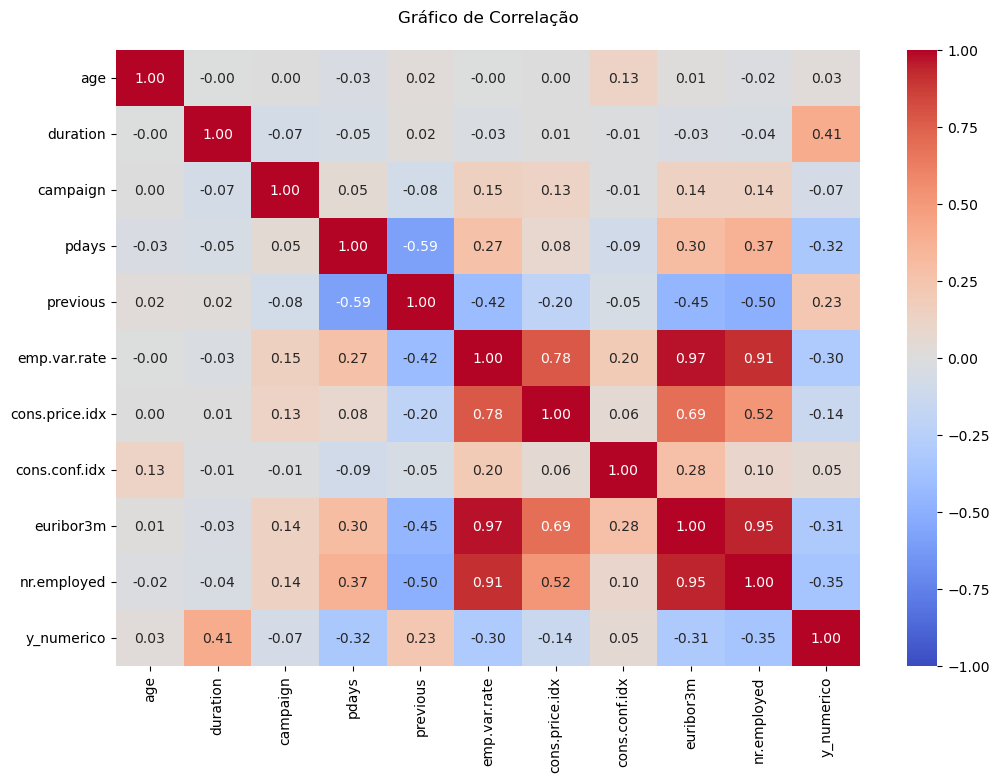

In [6]:
df_grafico = df.copy()

df_grafico['y_numerico'] = df_grafico['y'].map({'yes': 1, 'no': 0})

df_numerico = df_grafico.select_dtypes(include=['number'])

matriz_corr = df_numerico.corr()

# 5. Plotamos o Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, 
            annot=True,       
            cmap='coolwarm',     
            fmt=".2f",          
            vmin=-1, vmax=1)    

plt.title("Gráfico de Correlação", pad=20)
plt.show()

### Removendo duration para evitar data leak além de emp.var.rate e euribor3m que são semelhantes a nr.employed então se olhar a correlação, da para deixar apenas o nr.employed.

In [7]:
df_limpo = df.drop(['duration','emp.var.rate', 'euribor3m'], axis=1)

In [8]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  cons.price.idx  41188 non-null  float64
 15  cons.conf.idx   41188 non-null  float64
 16  nr.employed     41188 non-null  float64
 17  y               41188 non-null 

In [9]:
colunas = ['job', 'marital', 'education', 'contact']

# Conta quantos 'unknown' existem em cada uma dessas colunas
contagem_unknown = (df_limpo[colunas] == 'unknown').sum()

print(contagem_unknown)

job           330
marital        80
education    1731
contact         0
dtype: int64


### Fazendo hot encoding das variaveis

In [10]:
object_columns = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=object_columns, dtype=int)

In [11]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 65 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            41188 non-null  int64  
 1   duration                       41188 non-null  int64  
 2   campaign                       41188 non-null  int64  
 3   pdays                          41188 non-null  int64  
 4   previous                       41188 non-null  int64  
 5   emp.var.rate                   41188 non-null  float64
 6   cons.price.idx                 41188 non-null  float64
 7   cons.conf.idx                  41188 non-null  float64
 8   euribor3m                      41188 non-null  float64
 9   nr.employed                    41188 non-null  float64
 10  job_admin.                     41188 non-null  int64  
 11  job_blue-collar                41188 non-null  int64  
 12  job_entrepreneur               41188 non-null 

#otimização de canal de contato


In [12]:
# Verifica a taxa de conversão (y_yes) para cada canal isoladamente
taxa_celular = df_encoded[df_encoded['contact_cellular'] == 1]['y_yes'].mean()
taxa_telefone = df_encoded[df_encoded['contact_telephone'] == 1]['y_yes'].mean()

print(f"Conversão Histórica Celular: {taxa_celular:.4f} ({(taxa_celular*100):.2f}%)")
print(f"Conversão Histórica Telefone: {taxa_telefone:.4f} ({(taxa_telefone*100):.2f}%)")

# Definindo o Baseline
melhor_canal = "Celular" if taxa_celular > taxa_telefone else "Telefone"
taxa_baseline = max(taxa_celular, taxa_telefone)

print(f"MÉTRICA DO BASELINE: Sempre usar o {melhor_canal}")
print(f"TAXA A SER BATIDA PELO MODELO: {(taxa_baseline*100):.2f}%")

Conversão Histórica Celular: 0.1474 (14.74%)
Conversão Histórica Telefone: 0.0523 (5.23%)
MÉTRICA DO BASELINE: Sempre usar o Celular
TAXA A SER BATIDA PELO MODELO: 14.74%


# Preparando os dados para o modelo entender o Contexto

In [13]:
#Removendo o target das variáveis de treino.
X = df_encoded.drop(['y_yes', 'y_no'], axis=1)
y = df_encoded['y_yes']

#Treinando o modelo para aprender as probabilidades (A inteligência por trás do Epsilon-Greedy)
print("Treinando o modelo de contexto...")
modelo_contexto = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
modelo_contexto.fit(X, y)





Treinando o modelo de contexto...


RandomForestClassifier(max_depth=5, random_state=42)

# 2. Simular a Política Epsilon-Greedy

In [14]:

epsilon = 0.10 # 10% Exploração (aleatório) / 90% Explotação (inteligência do modelo)
acoes_escolhidas = []

# Prevendo a probabilidade de conversão se usarmos Celular ou Telefone para TODOS os clientes
X_celular = X.copy()
X_celular['contact_cellular'] = 1
X_celular['contact_telephone'] = 0
prob_celular = modelo_contexto.predict_proba(X_celular)[:, 1]

X_telefone = X.copy()
X_telefone['contact_cellular'] = 0
X_telefone['contact_telephone'] = 1
prob_telefone = modelo_contexto.predict_proba(X_telefone)[:, 1]

# Aplicando a regra do Epsilon-Greedy para cada cliente
np.random.seed(42)
for p_cel, p_tel in zip(prob_celular, prob_telefone):
    if np.random.rand() < epsilon:
        # FASE DE EXPLORAÇÃO: Sorteia um canal ignorando o modelo
        escolha = "contact_cellular" if np.random.rand() < 0.5 else "contact_telephone"
    else:
        # FASE DE EXPLOTAÇÃO: Escolhe o canal com maior probabilidade prevista pelo modelo
        escolha = "contact_cellular" if p_cel >= p_tel else "contact_telephone"
    
    acoes_escolhidas.append(escolha)

df_encoded['acao_algoritmo'] = acoes_escolhidas

# 3. Avaliação Offline (Replay Method)

In [15]:
# Só podemos avaliar o acerto quando a escolha do algoritmo coincide com o que realmente aconteceu no dataset
df_match = df_encoded[
    ((df_encoded['contact_cellular'] == 1) & (df_encoded['acao_algoritmo'] == 'contact_cellular')) |
    ((df_encoded['contact_telephone'] == 1) & (df_encoded['acao_algoritmo'] == 'contact_telephone'))
]

taxa_algoritmo = df_match['y_yes'].mean()

print("\n" + "-"*40)
print(f"---> TAXA DO BASELINE (Regra Fixa): 14.74%")
print(f"---> TAXA DO EPSILON-GREEDY CONTEXTUAL: {(taxa_algoritmo*100):.2f}%")
print("-"*40)

if taxa_algoritmo > 0.1474:
    ganho = ((taxa_algoritmo - 0.1474) / 0.1474) * 100
    print(f"SUCESSO! O modelo superou o baseline com um ganho relativo de {ganho:.2f}% na conversão.")
else:
    print("O modelo não superou o baseline. Tente ajustar os parâmetros (max_depth) ou o valor de Epsilon.")


----------------------------------------
---> TAXA DO BASELINE (Regra Fixa): 14.74%
---> TAXA DO EPSILON-GREEDY CONTEXTUAL: 16.11%
----------------------------------------
SUCESSO! O modelo superou o baseline com um ganho relativo de 9.29% na conversão.


In [16]:
# Sorteando 5 clientes aleatórios para o nosso Golden Set
np.random.seed(42) # Mantendo a semente para reprodutibilidade
indices_golden = df_encoded.sample(5, random_state=123).index
golden_set = df_encoded.loc[indices_golden].copy()

# Criando um DataFrame simplificado apenas com informações visuais para a banca
tabela_exibicao = pd.DataFrame()
tabela_exibicao['Idade'] = golden_set['age']

# Revertendo o One-Hot do 'job' para texto legível
jobs_cols = [col for col in golden_set.columns if col.startswith('job_')]
tabela_exibicao['Profissao'] = golden_set[jobs_cols].idxmax(axis=1).str.replace('job_', '')

# Revertendo o One-Hot do 'education'
edu_cols = [col for col in golden_set.columns if col.startswith('education_')]
tabela_exibicao['Educacao'] = golden_set[edu_cols].idxmax(axis=1).str.replace('education_', '')

tabela_exibicao['Qtd_Contatos_Campanha'] = golden_set['campaign']
tabela_exibicao['Contato_Anterior'] = golden_set['previous']

# Recomendação do algoritmo
tabela_exibicao['Canal_Recomendado'] = golden_set['acao_algoritmo'].map({
    'contact_cellular': 'Celular', 
    'contact_telephone': 'Telefone Fixo'
})


# GOLDEN SET SIMPLIFICADO (ETAPA 4)

In [17]:
display(tabela_exibicao)

,Idade,Profissao,Educacao,Qtd_Contatos_Campanha,Contato_Anterior,Canal_Recomendado
8107,42,services,high.school,4,0,Celular
38463,37,blue-collar,basic.6y,1,0,Telefone Fixo
1933,41,blue-collar,basic.6y,4,0,Celular
8352,42,admin.,university.degree,3,0,Celular
37164,56,entrepreneur,high.school,5,1,Celular


# Análise do Golden Set (Casos de Teste)

alguma descrição.


# ETAPA 5: SERVIÇO/INTERFACE

In [18]:
def recomendar_canal(idade, profissao, educacao, sucesso_anterior=False, forcar_exploracao=False):
    print(f"Analisando perfil: {idade} anos, {profissao}, {educacao} | Comprou antes? {sucesso_anterior}")
    
    # Cria um "esqueleto" vazio
    cliente = pd.DataFrame(columns=X.columns)
    cliente.loc[0] = 0 
    
    # Preenche variáveis básicas para o modelo não se assustar com "zeros"
    cliente['age'] = idade
    cliente['marital_married'] = 1
    cliente['housing_yes'] = 1
    cliente['loan_no'] = 1
    cliente['month_may'] = 1
    
    if f'job_{profissao}' in cliente.columns:
        cliente[f'job_{profissao}'] = 1
    if f'education_{educacao}' in cliente.columns:
        cliente[f'education_{educacao}'] = 1
        
    # Variável de peso forte: O cliente já aceitou uma oferta no passado?
    if sucesso_anterior:
        cliente['poutcome_success'] = 1
    else:
        cliente['poutcome_nonexistent'] = 1

    # Calcula as probabilidades reais (A Inteligência)
    cliente_celular = cliente.copy()
    cliente_celular['contact_cellular'] = 1
    cliente_celular['contact_telephone'] = 0
    prob_cel = modelo_contexto.predict_proba(cliente_celular)[:, 1][0]
    
    cliente_telefone = cliente.copy()
    cliente_telefone['contact_cellular'] = 0
    cliente_telefone['contact_telephone'] = 1
    prob_tel = modelo_contexto.predict_proba(cliente_telefone)[:, 1][0]
    
    print(f"   -> Confiança do modelo - Celular: {prob_cel*100:.1f}% | Telefone: {prob_tel*100:.1f}%")
    
    # Aplica a Política Epsilon-Greedy (A Adaptação)
    epsilon = 0.10 # 10% de chance de explorar
    
    if forcar_exploracao or (np.random.rand() < epsilon):
        # Modo Exploração (Sorteio para descobrir novos padrões)
        canal_escolhido = "Celular" if np.random.rand() < 0.5 else "Telefone Fixo"
        motivo = "EXPLORAÇÃO (Sorteio Adaptativo Epsilon-Greedy de 10%)"
    else:
        # Modo Explotação (Usa a inteligência do modelo)
        canal_escolhido = "Celular" if prob_cel >= prob_tel else "Telefone Fixo"
        motivo = "EXPLOTAÇÃO (Maior probabilidade de conversão identificada)"

    print(f"AÇÃO: Ligar via {canal_escolhido}")
    print(f"ESTRATÉGIA: {motivo}")
    print("-" * 65)

# ==========================================
# TESTES PARA A APRESENTAÇÃO
# ==========================================
np.random.seed(42) # Mantendo a semente para o teste 2 cair na exploração propositalmente

# Teste 1: Jovem sem histórico
print("=== TESTE 1: Perfil Comum ===")
recomendar_canal(idade=25, profissao='student', educacao='high.school', sucesso_anterior=False)

# Teste 2: O Epsilon-Greedy agindo (Cairá na exploração aleatória)
print("\n=== TESTE 2: Comportamento Adaptativo (Exploração) ===")
recomendar_canal(idade=55, profissao='retired', educacao='basic.4y', sucesso_anterior=False,forcar_exploracao=True)

# Teste 3: Cliente VIP (Forçando o modelo a mudar a probabilidade por causa do histórico)
print("\n=== TESTE 3: Perfil Alta Conversão ===")
recomendar_canal(idade=40, profissao='management', educacao='university.degree', sucesso_anterior=True)

=== TESTE 1: Perfil Comum ===
Analisando perfil: 25 anos, student, high.school | Comprou antes? False
   -> Confiança do modelo - Celular: 30.6% | Telefone: 30.1%
AÇÃO: Ligar via Celular
ESTRATÉGIA: EXPLOTAÇÃO (Maior probabilidade de conversão identificada)
-----------------------------------------------------------------

=== TESTE 2: Comportamento Adaptativo (Exploração) ===
Analisando perfil: 55 anos, retired, basic.4y | Comprou antes? False
   -> Confiança do modelo - Celular: 31.8% | Telefone: 30.2%
AÇÃO: Ligar via Telefone Fixo
ESTRATÉGIA: EXPLORAÇÃO (Sorteio Adaptativo Epsilon-Greedy de 10%)
-----------------------------------------------------------------

=== TESTE 3: Perfil Alta Conversão ===
Analisando perfil: 40 anos, management, university.degree | Comprou antes? True
   -> Confiança do modelo - Celular: 41.0% | Telefone: 40.3%
AÇÃO: Ligar via Celular
ESTRATÉGIA: EXPLOTAÇÃO (Maior probabilidade de conversão identificada)
----------------------------------------------------

# ETAPA 7: CICLO DE VIDA MLOPS (MLflow)

In [19]:
# Configurando o nome do experimento
mlflow.set_experiment("Datathon_Otimizacao_Canais")

# Iniciando o registro (Tracking)
with mlflow.start_run(run_name="Epsilon_Greedy_RandomForest"):
    
    # Registrando os parâmetros usados na Etapa 3
    mlflow.log_param("algoritmo_adaptativo", "Epsilon-Greedy")
    mlflow.log_param("modelo_base", "RandomForestClassifier")
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("epsilon", 0.10)
    
    # Registrando as métricas de conversão para provar a melhoria
    mlflow.log_metric("taxa_baseline_fixa", 0.1474) 
    mlflow.log_metric("taxa_epsilon_greedy", taxa_algoritmo) 
    
    # Registrando o próprio modelo treinado
    mlflow.sklearn.log_model(modelo_contexto, "modelo_contexto_rf")
    
    print("Experimento, parâmetros e métricas registrados com sucesso no MLflow!")

2026/08/27 19:50:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Experimento, parâmetros e métricas registrados com sucesso no MLflow!
